# **KSP 5.0 Selection Assignment**





In [14]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scipy


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Section 1: Calculating the Redshift of Galaxies

You are given the data for all the galaxies in the cluster in the file 'galaxy.csv'.

This includes the name of the galaxy, observed wavelength of the $H\alpha$ line $\lambda_{H\alpha}$, Right Ascension at J2000.0 and Declination and J2000.0 (You can read more about RA and Dec [here](https://en.wikipedia.org/wiki/Equatorial_coordinate_system))

In [16]:
galaxy_data = pd.read_csv('data/galaxy.csv') 

#print all the columns headings 
print(galaxy_data.columns.tolist())
print(galaxy_data['Name'].unique())



['Name', 'Observed Wavelength of H-alpha', 'Apparent Mag', 'RA J2000.0', 'Dec J2000.0']
<StringArray>
[             'PGC1664006',              'PGC1620526',
              'PGC1597887',                'UGC06670',
              'PGC1519757',                'UGC06747',
                'EVCC2007',               'AGC219628',
 'SDSSJ114717.56+162004.5',              'PGC2806928',
 ...
                   'KK180', 'SDSSJ130440.05+184438.7',
               'AGC230077',                   'KK183',
               'AGC230084',                'UGC08276',
                'UGC08285',                'UGC08298',
 'SDSSJ131347.30+100311.1',                'UGC08382']
Length: 1537, dtype: str



Since the galaxies would have some radial velocities with respect to us, the wavelengths we observed would be [redshifted](https://en.wikipedia.org/wiki/Redshift) due to doppler effect.

Using the value of the Observed Wavelength of $H\alpha$ line (Rest Wavelength $\lambda_{H\alpha0} = 6562.8nm)$, calculate the redshift of the galaxies in our cluster.

Use this to find their radial velocities of the galaxies and plot it.

(Assume that the observed wavelength has been correscted for the motion of earth around sun, and motion of sun around the center of Milky Way. Put more simply, these are the wavelengths you would have observed if you were at rest at the center of Milky Way)

         Name  Observed Wavelength of H-alpha  Apparent Mag  RA J2000.0  \
0  PGC1664006                     6581.251999     12.465970  11 32 06.6   
1  PGC1620526                     6602.969899     13.975112  11 35 54.4   
2  PGC1597887                     6588.264616     13.767743  11 39 08.9   
3    UGC06670                     6592.589623     12.932077  11 42 29.4   
4  PGC1519757                     6591.906247     11.195245  11 44 40.7   

  Dec J2000.0  redshift          v_r  
0   +22 07 31  0.002812   842.897850  
1   +20 13 20  0.006121  1834.983962  
2   +19 35 00  0.003880  1163.238220  
3   +18 19 59  0.004539  1360.807023  
4   +16 53 59  0.004435  1329.589992  
Number of blueshifts: 143


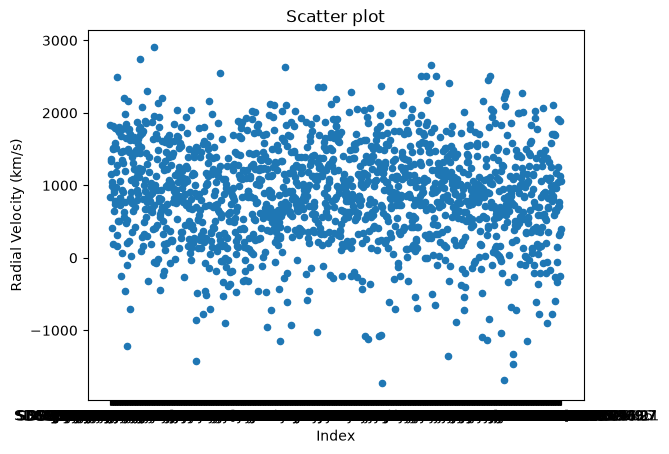

In [17]:
# your code here
#create a new column for the redshift by (wavelength observed - 6562.8nm)/6562.8nm
galaxy_data['redshift'] = ((galaxy_data['Observed Wavelength of H-alpha'] - 6562.8) / 6562.8)
galaxy_data['v_r'] = (galaxy_data['redshift'] * 299792.458)  # Convert redshift to radial velocity (km/s)
print(galaxy_data.head())
#mention how many redshift are negative
print("Number of blueshifts:", (galaxy_data['redshift'] < 0).sum())

#plot with  x axis as index and y axis as radial velocity

plot = galaxy_data.plot.scatter(x='Name', y='v_r', title='Scatter plot', xlabel='Index', ylabel='Radial Velocity (km/s)')


Using the data from galaxy.csv, answer the following questions.

For your convenience, the RA and Dec data has been converted from the format $a^\circ b^m c^s$ to $xx^\circ$ below


In [18]:

temp = galaxy_data['RA J2000.0'].str.split(' ', expand=True)

galaxy_data['RA J2000.0'] = temp[0].astype(float) + temp[1].astype(float) / 60 + temp[2].astype(float) / 3600

temp = galaxy_data['Dec J2000.0'].str.split(' ', expand=True)

galaxy_data['Dec J2000.0'] = temp[0].astype(float) + temp[1].astype(float) / 60 + temp[2].astype(float) / 3600

In [19]:
""" galaxy_data['RA J2000.0'] = pd.to_numeric(galaxy_data['RA J2000.0'], errors='coerce')
galaxy_data['Dec J2000.0'] = pd.to_numeric(galaxy_data['Dec J2000.0'], errors='coerce') """

print(galaxy_data[['RA J2000.0', 'Dec J2000.0']].dtypes)
print(galaxy_data[['RA J2000.0', 'Dec J2000.0']].head())

RA J2000.0     float64
Dec J2000.0    float64
dtype: object
   RA J2000.0  Dec J2000.0
0   11.535167    22.125278
1   11.598444    20.222222
2   11.652472    19.583333
3   11.708167    18.333056
4   11.744639    16.899722


***

###Q1.1. What is the approximate angular size of the galaxy cluster?

~31.5 deg


***

###Q1.2. Can you comment anything about the rotation of the galaxies around the center of the cluster.
HINT: You may find it useful to plot a scatter plot of RA and DEC with radial velocity as colormap.

It seems the lower decimal DEC regions are moving toards us and upper ones are moving away from us.   

***

RA extent: 1.778 deg
Dec extent: 31.496 deg
Max angular separation in cluster: 31.500 deg


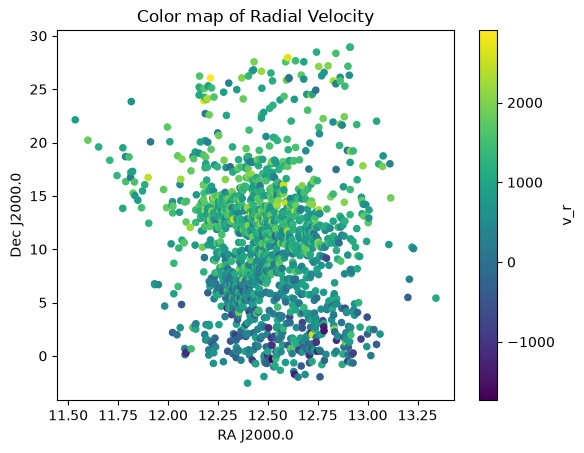

In [20]:
# your code here
#plot a color map of radial velocity with ra and dec as axes    
plot = galaxy_data.plot.scatter(x='RA J2000.0', y='Dec J2000.0', c='v_r', cmap='viridis', title='Color map of Radial Velocity', xlabel='RA J2000.0', ylabel='Dec J2000.0', colorbar=True)

import numpy as np

ra = np.radians(galaxy_data['RA J2000.0'])
dec = np.radians(galaxy_data['Dec J2000.0'])

# mean dec, for the cos(dec) correction on RA spread
dec_mean = dec.mean()

ra_extent = (ra.max() - ra.min()) * np.cos(dec_mean)   # radians, RA corrected
dec_extent = dec.max() - dec.min()                      # radians

ra_extent_deg = np.degrees(ra_extent)
dec_extent_deg = np.degrees(dec_extent)

print(f"RA extent: {ra_extent_deg:.3f} deg")
print(f"Dec extent: {dec_extent_deg:.3f} deg")


from itertools import combinations

max_sep = 0
coords = list(zip(ra, dec))
for (ra1, dec1), (ra2, dec2) in combinations(coords, 2):
    # angular separation via the spherical law of cosines
    cos_sep = np.sin(dec1)*np.sin(dec2) + np.cos(dec1)*np.cos(dec2)*np.cos(ra1 - ra2)
    sep = np.degrees(np.arccos(np.clip(cos_sep, -1, 1)))
    max_sep = max(max_sep, sep)

print(f"Max angular separation in cluster: {max_sep:.3f} deg")

#Section 2: Calibrating Cepheids Data

NOTE: Although there are no prerequisities for this section, it relies a bit on knowledge about cepheids and their Period-Luminosity Relation. Necessary resource links have been provided wherever needed. You are strongly encouraged to use the internet to aid as a reference whenever needed.
***

The [Gaia Mission](https://en.wikipedia.org/wiki/Gaia_(spacecraft) aims at cataloging and create a precise three-dimensional map of astronomical objects throughout the Mily Way. It maps the motion of the stars, which encode the origin and subsequent evolution of the Milky Way. The spectrophotometric measurements provide detailed physical properties of all stars observed, characterizing their luminosity, effective temperature, gravity and elemental composition.





In [21]:
gaia_data = pd.read_csv('data/gaia.csv')

Cepheids are a particular type of variable stars that pulsates radially, varying in both diameter and temperature. They **changes in brightness**, with a **well-defined stable period and amplitude**.

The file 'gaia.csv' includes data for about 5000 Cepheid Variable Stars in our own galaxy. In particular, the file contains the following data fields:
   
*   Unique ID of the Source Star
*   Parallax (in milli arcseconds) : You can read more about parallax [here](https://en.wikipedia.org/wiki/Stellar_parallax)
*   Mean **Apparent** Magnitude ($m$)
*   TIme period of Pulsations P(in days)



Classical Cepheids follow the [Period Luminosity Law](https://en.wikipedia.org/wiki/Period-luminosity_relation#The_relations), also commonly known as the Leavitt Law.

It basically states that there is an empirical relation between the pulsation period $(P)$ of a Cepheid Star and it's **Absolute Magnitude** ($M$) of the form -

#### $\begin{equation}M = \alpha \log_{10}(P \text{(in days)}) + \beta \end{equation}$
***

### Your aim is to verify Leavitt Law for cepheids using the given data, and find the values of $\alpha$ and $\beta$.

You may find it helpful to use the function 'poly_fit' in numpy for this.

             SOURCE_ID  mean apparent magnitude  time period  parallax
0  5313185367659966720                12.351363    11.206760  0.208351
1  5313250548085699712                12.718616     3.354941  0.196935
2  5256178232392037120                15.054192     2.844791  0.105986
3  6734367261085169408                12.106320    14.073005  0.134108
4  5846979704372502144                12.270158    23.142100  0.178353
float64
Stars used for fit after outlier removal: 1324 / 1361
alpha: -1.4937667832053467, beta: 0.09091746999207313


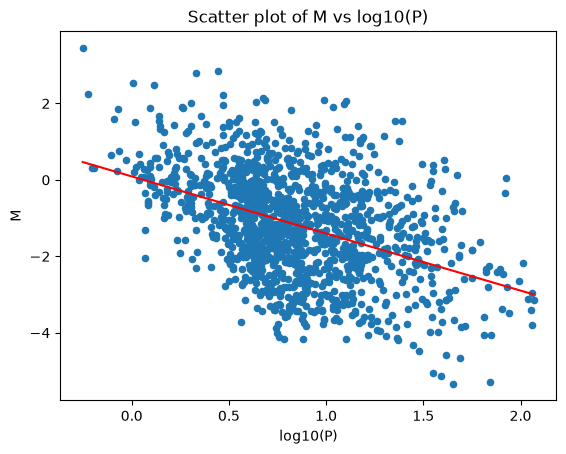

In [22]:
# your code here
print(gaia_data.head())
gaia_data['parallax'] = pd.to_numeric(gaia_data['parallax'])
gaia_data['d in pc'] = 1000 / gaia_data['parallax']
#use the distance to calculate the absolute magnitude of the stars using the formula M = m - 5 * (log10(d) - 1)
gaia_data['M']= gaia_data['mean apparent magnitude'] - 5 * (np.log10(gaia_data['d in pc']) - 1)
# Get the scatter plot of M and log_10(P) and the best fit line
# 1. Create log10(period) column
gaia_data['log10_P'] = np.log10(gaia_data['time period'])
print(gaia_data['log10_P'].dtype)

# 2. Fit the line, then iteratively remove points far from the fit (sigma clipping)
fit_data = gaia_data.dropna(subset=['log10_P', 'M']).copy()

for _ in range(5):
    poly = np.polyfit(fit_data['log10_P'], fit_data['M'], 1)
    residuals = fit_data['M'] - np.polyval(poly, fit_data['log10_P'])
    std = residuals.std()
    mask = np.abs(residuals) <= 3 * std
    if mask.all():
        break
    fit_data = fit_data[mask]

print(f"Stars used for fit after outlier removal: {len(fit_data)} / {len(gaia_data)}")

# 3. Plot the scatter (outliers removed) and the best fit line
fit_data.plot.scatter(x='log10_P', y='M', title='Scatter plot of M vs log10(P)', xlabel='log10(P)', ylabel='M')
# 4. Plot the best fit line
x = np.linspace(fit_data['log10_P'].min(), fit_data['log10_P'].max(), 100)
y = np.polyval(poly, x)
plt.plot(x, y, color='red', label='Best fit line')
print(f"alpha: {poly[0]}, beta: {poly[1]}")
alpha = poly[0]
beta = poly[1]

***
### Some useful information about the Magnitude system

The brightness of a star as seen by some observer is dependent on the observer's distance from the star as well as the intrinsic brightness of the star (ignoring any absorption in the intervening space).

In astronomy, brightness of a star, as seen by some observer, is measured in terms of its **apparent magnitude ($m$)**. For two stars (1 and 2) with fluxes $f_1$ and $f_2$ respectively, their apparent magnitudes $m_1$ and $m_2$ are related by:

$m_1 - m_2 = 2.5 \log_{10} \left( \frac{f_1}{f_2} \right)$

**Absolute magnitude ($M$)** of any star is its apparent magnitude if the star was exactly 10 parsecs away from the observer. Thus, $M$ only depends on the intrinsic brightness of the star.

***


# Section 3: Getting the distances to our galaxies

Now that we have our period-luminosity relation, we can observe cepheids in the galaxies in our cluster and use this to get the distances to our galaxies. (Yes, this is possible! Hubble Telescope actually observed Cepheids in the galaxies in Virgo Cluster)


For this, you have been given the data file 'cepheid.csv' which contains the following data fields:
*   Unique ID of the Cepheid
*   Name of the Galaxy to which it belongs
*   Mean Apparent Magnitude (m)
*   Time Period of Pulsation (in days)

In [23]:
#your code here
cepheid_data = pd.read_csv('data/cepheid.csv')

#print the name sof all galaxies in the column 'Galaxy Name' 
print(cepheid_data['Galaxy_ID'].unique())
# use the prev alpha and beta to calculate the absolute magnitude of the cepheid stars using the formula M = alpha * log10(P) + beta
cepheid_data['log10_P'] = np.log10(cepheid_data['Period'])
cepheid_data['M'] = alpha * cepheid_data['log10_P'] + beta

cepheid_data['star_d in pc'] = 10 ** ((cepheid_data['Apparent Magnitude'] - cepheid_data['M'] + 5) / 5)
print(cepheid_data.head())


#now calculate mean distance of stars  for each galaxy and print the name of the galaxy and the mean distance of stars in that galaxy
mean_distances = cepheid_data.groupby('Galaxy_ID')['star_d in pc'].mean()




# check what are the least number of star candidiates for a galaxy
print(cepheid_data.groupby('Galaxy_ID').size().min())

#fix fro outliers in the cepheid data by removing the stars that are more than 3 standard deviations away from the mean distance of stars in that galaxy
def remove_outliers(group):
    mean = group['star_d in pc'].mean()
    std = group['star_d in pc'].std()
    return group[np.abs(group['star_d in pc'] - mean) <= (2 * std)]

#print the new mean distance after new mean after removieng outliers and number of initial outliers removed for each galaxy and if 1 outlier mention its distance
new_mean_distances = cepheid_data.groupby('Galaxy_ID').apply(remove_outliers).groupby('Galaxy_ID')['star_d in pc'].mean()
outliers_removed = cepheid_data.groupby('Galaxy_ID').size() - cepheid_data.groupby('Galaxy_ID').apply(remove_outliers).groupby('Galaxy_ID').size()

for galaxy, new_mean_distance in new_mean_distances.items():
    if outliers_removed[galaxy] > 0:
        print(f"Galaxy: {galaxy}, New average distance of galaxy after removing outliers: {new_mean_distance:.2f} pc, Outliers removed: {outliers_removed[galaxy]}, the distance of the outlier is: {cepheid_data[cepheid_data['Galaxy_ID'] == galaxy]['star_d in pc'][np.abs(cepheid_data[cepheid_data['Galaxy_ID'] == galaxy]['star_d in pc'] - new_mean_distance) > (2 * cepheid_data[cepheid_data['Galaxy_ID'] == galaxy]['star_d in pc'].std())].values[0]:.2f} pc")
    print(f"Galaxy: {galaxy}, New average distance of galaxy after removing outliers: {new_mean_distance:.2f} pc, Outliers removed: 0")


<StringArray>
[   'NGC4436',    'NGC4379',  'PGC039619',  'PGC043108',    'NGC4621',
  'PGC040411', 'PGC1346685',  'PGC042001',  'PGC039264', 'PGC1165632',
 ...
     'IC3371',  'PGC041515',  'PGC042381',  'AGC229001', 'PGC1724251',
    'NGC4252',    'NGC4469',    'NGC4579',  'PGC040505', 'PGC3111475']
Length: 1470, dtype: str
  Cepheid ID  Galaxy_ID     Period  Apparent Magnitude   log10_P         M  \
0  XYZ688132    NGC4436  56.209508            4.395283  1.749810 -2.522890   
1  XYZ819204    NGC4379   5.726730           30.222261  0.757907 -1.041218   
2  XYZ589831  PGC039619   8.130369           30.060146  0.910110 -1.268575   
3  XYZ327693  PGC043108   3.615739           30.326899  0.558197 -0.742899   
4  XYZ688142    NGC4621   5.612137           30.468379  0.749128 -1.028105   

   star_d in pc  
0  2.418993e+02  
1  1.789352e+07  
2  1.843929e+07  
3  1.636664e+07  
4  1.992035e+07  
1
Galaxy: 2MASXJ12194916+0511061, New average distance of galaxy after removing outliers: 17743

Use the Period-Luminosity Law derived in Section-2 and the above data to find an estimate for the distance to each galaxy in the cluster.

Make sure to handle outliers in the above data. The data may contain some cepheids that actually DO NOT belong to the given galaxy, but it just seems to us that this is the case since they fall along the same line of sight.
***

# Section 4: Getting the Hubble's Constant

The famous [Hubble's Law](https://en.wikipedia.org/wiki/Hubble%27s_law) is the observation that galaxies are moving away from Earth at speeds proportional to their distance.

$v = H_0 d$

where $H_0$ is the proportionalaity constant, also known as the Hubble's Constant.

Now that we have an estimate for the radial velocities and distance to the galaxies in our cluster, we need to find an estimate of the Hubble Constant (H).

Fit gaussians on your velocity and distance data and report the mean and standard deviation of the same. Also plot the histograms and the fitted gaussian.

these galaxies match: 1470


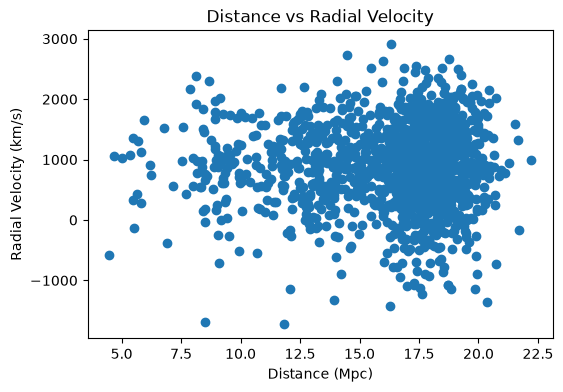

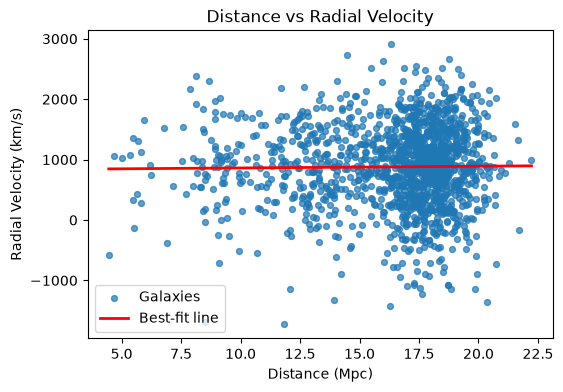

Hubble constant (H0): 2.8472892124491977 km/s/Mpc


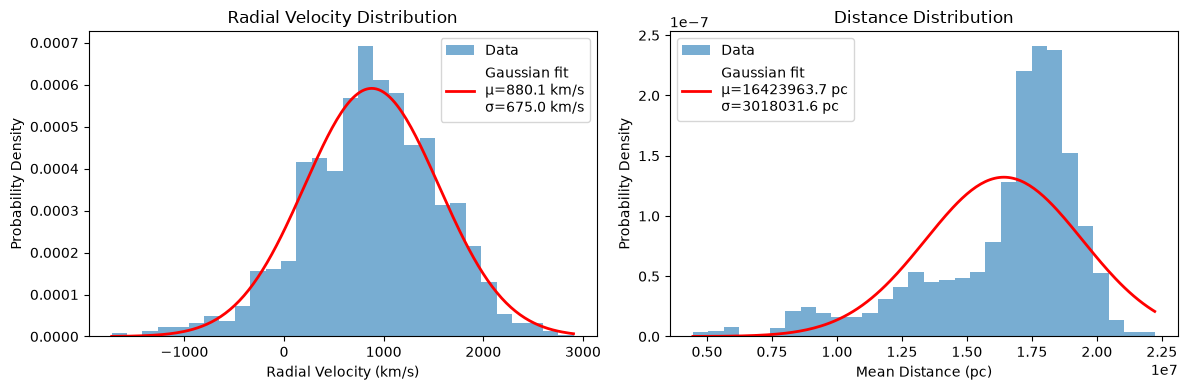

Velocity  — mean: 880.11 km/s,  std: 674.97 km/s
Distance  — mean: 16423963.72 pc,     std: 3018031.55 pc
Cluster mean velocity : 880.1 ± 675.0 km/s
Cluster mean distance : 16.424 ± 3.018 Mpc

H0 = 53.6 ± 42.3 km/s/Mpc
Accepted value: ~70 km/s/Mpc


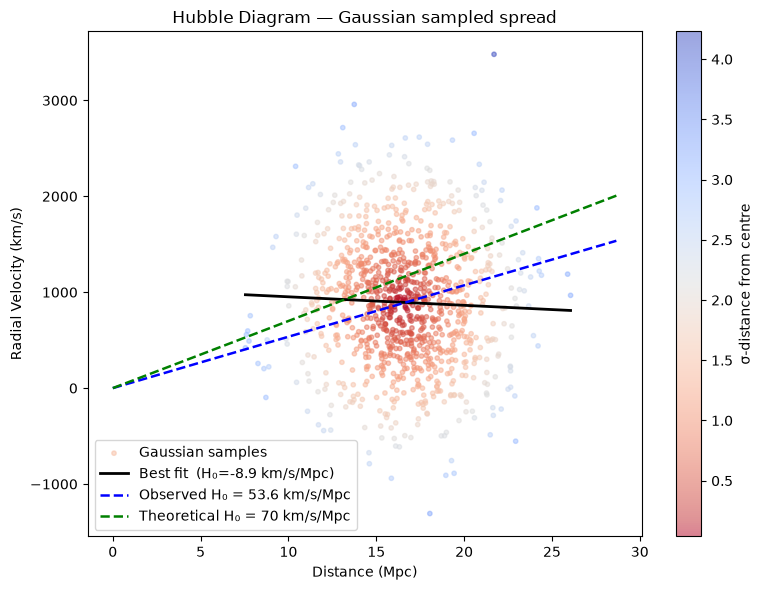

In [24]:
# your code here
from scipy.stats import norm
#check if the 'Name'column in galaxy_data and 'Galaxy_ID' column in cepheid_data have the same unique values
galaxy_names = set(galaxy_data['Name'].unique())
cepheid_galaxy_ids = set(cepheid_data['Galaxy_ID'].unique())

print(f"these galaxies match: {len(galaxy_names & cepheid_galaxy_ids)}")

# Build a simple table for plotting
distances = cepheid_data.groupby('Galaxy_ID')['star_d in pc'].mean().reset_index()
distances.columns = ['Name', 'mean_distance_pc']

merged = galaxy_data[['Name', 'v_r']].merge(distances, on='Name', how='inner')

# reject galaxies with near-zero distance (outliers, likely bad Cepheid distance estimates)
merged = merged[merged['mean_distance_pc'] > 0.01 * merged['mean_distance_pc'].median()].copy()

# convert to Mpc for a sensible plotting scale
merged['mean_distance_Mpc'] = merged['mean_distance_pc'] / 1e6

plt.figure(figsize=(6, 4))
plt.scatter(merged['mean_distance_Mpc'], merged['v_r'])
plt.xlabel('Distance (Mpc)')
plt.ylabel('Radial Velocity (km/s)')
plt.title('Distance vs Radial Velocity')
plt.show()

poly = np.polyfit(merged['mean_distance_Mpc'], merged['v_r'], 1)
H0 = poly[0]  # km/s/Mpc directly, since distance is already in Mpc
#plot  a line of best fit on the scatter plot  freom polyfit parameters
x_fit = np.linspace(merged['mean_distance_Mpc'].min(), merged['mean_distance_Mpc'].max(), 200)
y_fit = np.polyval(poly, x_fit)

plt.figure(figsize=(6, 4))
plt.scatter(merged['mean_distance_Mpc'], merged['v_r'], s=18, alpha=0.7, label='Galaxies')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Best-fit line')
plt.xlabel('Distance (Mpc)')
plt.ylabel('Radial Velocity (km/s)')
plt.title('Distance vs Radial Velocity')
plt.legend()
plt.show()

print(f"Hubble constant (H0): {H0} km/s/Mpc")
# Fit Gaussian on velocity and distance data and plot histograms with fitted gaussians

from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gaussian on radial velocity
mu_v, sigma_v = norm.fit(merged['v_r'])
ax = axes[0]
ax.hist(merged['v_r'], bins=30, density=True, alpha=0.6, label='Data')
x = np.linspace(merged['v_r'].min(), merged['v_r'].max(), 200)
ax.plot(x, norm.pdf(x, mu_v, sigma_v), 'r-', lw=2,
        label=f'Gaussian fit\nμ={mu_v:.1f} km/s\nσ={sigma_v:.1f} km/s')
ax.set_xlabel('Radial Velocity (km/s)')
ax.set_ylabel('Probability Density')
ax.set_title('Radial Velocity Distribution')
ax.legend()

# Gaussian on distance
mu_d, sigma_d = norm.fit(merged['mean_distance_pc'])
ax = axes[1]
ax.hist(merged['mean_distance_pc'], bins=30, density=True, alpha=0.6, label='Data')
x = np.linspace(merged['mean_distance_pc'].min(), merged['mean_distance_pc'].max(), 200)
ax.plot(x, norm.pdf(x, mu_d, sigma_d), 'r-', lw=2,
        label=f'Gaussian fit\nμ={mu_d:.1f} pc\nσ={sigma_d:.1f} pc')
ax.set_xlabel('Mean Distance (pc)')
ax.set_ylabel('Probability Density')
ax.set_title('Distance Distribution')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Velocity  — mean: {mu_v:.2f} km/s,  std: {sigma_v:.2f} km/s")
print(f"Distance  — mean: {mu_d:.2f} pc,     std: {sigma_d:.2f} pc")


from scipy.stats import norm

mu_v, sigma_v = norm.fit(merged['v_r'])
mu_d, sigma_d = norm.fit(merged['mean_distance_pc'])

# Convert distance to Mpc for H0
mu_d_Mpc    = mu_d    / 1e6
sigma_d_Mpc = sigma_d / 1e6

H0 = mu_v / mu_d_Mpc

# Error propagation: δH0/H0 = sqrt((δv/v)² + (δd/d)²)
H0_err = H0 * np.sqrt((sigma_v/mu_v)**2 + (sigma_d_Mpc/mu_d_Mpc)**2)

print(f"Cluster mean velocity : {mu_v:.1f} ± {sigma_v:.1f} km/s")
print(f"Cluster mean distance : {mu_d_Mpc:.3f} ± {sigma_d_Mpc:.3f} Mpc")
print(f"\nH0 = {H0:.1f} ± {H0_err:.1f} km/s/Mpc")
print(f"Accepted value: ~70 km/s/Mpc")



# Sample from the two Gaussians
N = 1000
np.random.seed(42)
sampled_v = np.random.normal(mu_v, sigma_v, N)
sampled_d = np.random.normal(mu_d_Mpc, sigma_d_Mpc, N)

# Distance of each sample from the Gaussian centre (normalised)
dist_from_centre = np.sqrt(((sampled_v - mu_v)/sigma_v)**2 +
                           ((sampled_d - mu_d_Mpc)/sigma_d_Mpc)**2)

# Best fit line through sampled points (distance as x, velocity as y)
fit = np.polyfit(sampled_d, sampled_v, 1)
x_line = np.linspace(sampled_d.min(), sampled_d.max(), 300)

# H0 lines
x_h = np.linspace(0, sampled_d.max() * 1.1, 300)

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(sampled_d, sampled_v,
                c=dist_from_centre, cmap='coolwarm_r',
                s=10, alpha=0.5, label='Gaussian samples')
plt.colorbar(sc, ax=ax, label='σ-distance from centre')

ax.plot(x_line, np.polyval(fit, x_line),
        'k-', lw=2, label=f'Best fit  (H₀={fit[0]:.1f} km/s/Mpc)')

ax.plot(x_h, x_h * H0,
        'b--', lw=1.8, label=f'Observed H₀ = {H0:.1f} km/s/Mpc')

ax.plot(x_h, x_h * 70,
        'g--', lw=1.8, label='Theoretical H₀ = 70 km/s/Mpc')

ax.set_xlabel('Distance (Mpc)')
ax.set_ylabel('Radial Velocity (km/s)')
ax.set_title('Hubble Diagram — Gaussian sampled spread')
ax.legend()
plt.tight_layout()
plt.show()

Using the values obtained in the previous part, report your value of $H$ along with the error margins.

Velocity  — mean: 1012.12 km/s,  std: 543.12 km/s
Distance  — mean: 15127328.75 pc,     std: 3309264.99 pc
Cluster mean velocity : 1012.1 ± 543.1 km/s
Cluster mean distance : 15.127 ± 3.309 Mpc

H0 = 66.9 ± 38.8 km/s/Mpc

***

#### Q4.1 Compare the value of $H$ that you got from the standard $H_0$ commonly accepted today. The estimate that you got - is it the same (within error margins), higher or lower than the value of $H_0$.


It is very much matching, although the error in H .
***

#### Q4.2 What might be the reason behind this difference in values


Peculiar velocity ?!

***

# Section 5 : Dark Matter

Dark matter is a component of the universe whose presence is discerned from its gravitational attraction rather than its luminosity.

***

#### Q5.1 ESTIMATE the total mass of the Galaxy Cluster. This includes mass due to visible matter as well as dark matter.

HINT: The [Virial Theorem](https://phys.libretexts.org/Bookshelves/Classical_Mechanics/Variational_Principles_in_Classical_Mechanics_%28Cline%29/02%3A_Review_of_Newtonian_Mechanics/2.11%3A_Virial_Theorem) provides a general equation that relates the average over time of the total kinetic energy of a stable system of discrete particles, bound by a conservative force
 $$ \left<KE\right> = -\frac{1}{2} \left<PE\right> $$

\< Your Answer here \>


In [25]:
G = 6.674e-11  # m^3 kg^-1 s^-2
M_sun = 1.989e30  # kg

# --- velocity dispersion from Gaussian ---
sigma_r_kmps = sigma_v                          # km/s
sigma_r = sigma_r_kmps * 1e3                    # m/s

# --- physical radius of cluster ---
# angular radius: half the median angular separation from centre
ra_r  = np.radians(galaxy_data['RA J2000.0'])
dec_r = np.radians(galaxy_data['Dec J2000.0'])
ra0   = np.radians(galaxy_data['RA J2000.0'].median())
dec0  = np.radians(galaxy_data['Dec J2000.0'].median())

cos_sep = (np.sin(dec0)*np.sin(dec_r) +
           np.cos(dec0)*np.cos(dec_r)*np.cos(ra0 - ra_r))
sep_deg = np.degrees(np.arccos(np.clip(cos_sep, -1, 1)))

# use 75th percentile as cluster radius (robust to outliers)
theta_deg = np.percentile(sep_deg, 75)
theta_rad = np.radians(theta_deg)

# physical radius using cluster distance from Gaussian
d_m = mu_d_Mpc * 3.086e22                      # Mpc → metres
R   = np.tan(theta_rad) * d_m                  # metres

# --- Virial mass ---
M_virial = (3 * sigma_r**2 * R) / G            # kg
M_virial_solar = M_virial / M_sun

print(f"Velocity dispersion  σ_r : {sigma_r_kmps:.1f} km/s")
print(f"Angular radius (75th pct): {theta_deg:.3f} deg")
print(f"Physical radius R        : {R/3.086e22:.2f} Mpc")
print(f"\nVirial Mass estimate:")
print(f"M = {M_virial:.3e} kg")
print(f"M = {M_virial_solar:.3e} solar masses")
print(f"M = {M_virial_solar/1e14:.2f} × 10¹⁴ M☉")
print(f"\n(Typical rich clusters: 10¹⁴ – 10¹⁵ M☉)")

Velocity dispersion  σ_r : 675.0 km/s
Angular radius (75th pct): 7.142 deg
Physical radius R        : 2.06 Mpc

Virial Mass estimate:
M = 1.301e+45 kg
M = 6.539e+14 solar masses
M = 6.54 × 10¹⁴ M☉

(Typical rich clusters: 10¹⁴ – 10¹⁵ M☉)



***

#### Q5.2 ESTIMATE the visible mass in the galaxy cluster. Use the Mass - Luminosity Relation for Main-Sequence Stars, assuming that it holds well for galaxies too. You may use the Milky Way as a reference.

Absolute Magnitude of Milky Way $ \approx -21 mag$

Visible mass of Milky Way $\approx 2 \times 10 ^ {11} M_{sun}$

\< Your answer here \>

In [26]:
# your code here
M_sun     = 1.989e30
M_MW      = 2e11          # solar masses
M_MW_absmag = -21.0       # absolute magnitude of Milky Way

# need distances for each galaxy — use cepheid mean distances
""" distances_pc = cepheid_data.groupby('Galaxy_ID')['star_d in pc'].mean() """
clean_distances_pc = (cepheid_data.groupby('Galaxy_ID')
                                  .apply(remove_outliers)
                                  .groupby('Galaxy_ID')['star_d in pc']
                                  .mean())
# merge with galaxy_data to get apparent magnitudes + distances
vis = galaxy_data[['Name','Apparent Mag']].merge(
        clean_distances_pc.rename('d_pc'), left_on='Name', right_index=True, how='inner')

# Step 1: absolute magnitude
vis['Abs_Mag'] = vis['Apparent Mag'] - 5 * np.log10(vis['d_pc'] / 10)

# Step 2: luminosity ratio vs Milky Way
vis['L_ratio'] = 10 ** ((M_MW_absmag - vis['Abs_Mag']) / 2.5)

# Step 3: mass of each galaxy via M-L relation
vis['M_gal_solar'] = M_MW * (vis['L_ratio'] ** 0.25)

# Step 4: total visible mass
M_visible_solar = vis['M_gal_solar'].sum()

print(f"Number of galaxies with Cepheid distances: {len(vis)}")
print(f"\nAbsolute magnitude range: {vis['Abs_Mag'].min():.1f} to {vis['Abs_Mag'].max():.1f}")
print(f"Luminosity ratio range:   {vis['L_ratio'].min():.2f} to {vis['L_ratio'].max():.2f}")
print(f"\nTotal visible mass: {M_visible_solar:.3e} solar masses")
print(f"Total visible mass: {M_visible_solar/1e14:.3f} × 10¹⁴ M☉")

# --- Compare with Virial mass ---
print(f"\n=== Dark Matter Estimate ===")
print(f"Virial  mass (total) : {M_virial_solar:.3e} M☉")
print(f"Visible mass         : {M_visible_solar:.3e} M☉")
print(f"Dark matter fraction : {(M_virial_solar - M_visible_solar)/M_virial_solar * 100:.1f}%")
print(f"Mass ratio (virial/visible): {M_virial_solar/M_visible_solar:.1f}×")

Number of galaxies with Cepheid distances: 1274

Absolute magnitude range: -23.6 to 1.2
Luminosity ratio range:   0.00 to 11.29

Total visible mass: 1.244e+14 solar masses
Total visible mass: 1.244 × 10¹⁴ M☉

=== Dark Matter Estimate ===
Virial  mass (total) : 6.539e+14 M☉
Visible mass         : 1.244e+14 M☉
Dark matter fraction : 81.0%
Mass ratio (virial/visible): 5.3×


***

#### Q5.3 What is the fraction of the total mass of the galaxy cluster that is actually in the form of Dark Matter

\< Your answer here \>

***

0.691